In [ ]:
import numpy as np
from scipy import stats
import pandas as pd 
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

metric_df = pd.read_csv("nl-metric.csv")
metric_columns = list(metric_df.columns)
print(metric_columns)
# metric_columns = ['bleu', 'bleu_1gram_precision', 'chrf1',
#        'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'rouge1_f1',
#        'rouge2_f1', 'rougeL_f1', 'meteor', 'js_divergence', 'coverage',
#        'density', 'compression', 'abstractivity', 'redundancy_r1',
#        'semantic_coherence', 'readability', ]
data_df = pd.read_csv("all_data.csv")
data_df.columns



['self_bleu', 'mover_score', 'WMD', 'sms', 'weem4ts', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'sent_bert', 'rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'rouge-w-1.2', 'rouge-s4', 'rouge-su4', 'perplexity', 'js_divergence', 'coverage', 'density', 'compression', 'semantic_coherence', 'redundancy_r1', 'redundancy_r2', 'redundancy_rL', 'abstractivity', 'abstraction_1gram', 'abstraction_2gram', 'uniformity', 'mtld', 'readability', 'sari', 'distinct_1', 'distinct_2', 'distinct_3', 'nist_1', 'bleu_1', 'bleu_1gram_precision_1', 'bleu_2gram_precision_2', 'bleu_3gram_precision_3', 'bleu_4gram_precision_4', 'meteor_1', 'chrf+_1', 'chrf++_1']


Index(['Unnamed: 0', 'enc_id', 'human reference', 'department', 'month',
       'generated letter', 'patient file', 'patientid', 'gpt_all_hallu_count',
       'gpt_all_omission_count', 'gpt_all_trivial_count',
       'gpt_important_hallu_count', 'gpt_important_omission_count',
       'gpt_important_trivial_count', 'gpt_usability', 'ref_all_hallu_count',
       'ref_all_omission_count', 'ref_all_trivial_count',
       'ref_important_hallu_count', 'ref_important_omission_count',
       'ref_usability', 'org_preprocessed', 'gpt_preprocessed', 'gpt_tokens',
       'org_tokens', 'clean human reference', 'source_preprocessed',
       'source_tokens'],
      dtype='object')

In [3]:
target_columns_all = ['gpt_all_hallu_count', 'gpt_all_omission_count', 'gpt_all_trivial_count', 'gpt_usability', 'gpt_tokens']
target_columns_important = ['gpt_important_hallu_count', 'gpt_important_omission_count', 'gpt_important_trivial_count']

### dataset statisitcs

In [5]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')  

def count_tokens(text):
    if pd.isna(text):
        return 0
    tokens = word_tokenize(text, language='dutch')
    return len(tokens)

data_df['source_tokens'] = data_df['source_preprocessed'].apply(count_tokens)
#data_df.to_csv("./data/all_data_may2026.csv")

[nltk_data] Downloading package punkt to /Users/ychen4/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
def format_stats(col):
    return (
        f"{col.mean():.1f} "
        f"(SD {col.std():.1f}, "
        f"median {col.median():.1f}, "
        f"IQR {col.quantile(0.25):.1f}-{col.quantile(0.75):.1f})"
    )

formatted = data_df[[
    "gpt_tokens",
    "org_tokens",
    "source_tokens"
]].apply(format_stats)

print(formatted)

gpt_tokens         320.3 (SD 100.4, median 304.0, IQR 240.0-384.0)
org_tokens         243.9 (SD 116.3, median 226.0, IQR 169.0-298.0)
source_tokens    4581.0 (SD 5018.2, median 2974.0, IQR 1763.0-5...
dtype: object


## Correlation
- Spearman correlation
- Kendall’s tau

In [7]:
# FOR ALL ERRORS 

combined_df_all = pd.concat([metric_df[metric_columns], data_df[target_columns_all]], axis=1).dropna()

# Dictionary to store results
results = {
    'metric': [],
    'target': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Function to compute correlation and p-value
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p


for metric in metric_columns:
    for target in target_columns_all: 
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            corr, p = compute_corr(method_func, combined_df_all[metric], combined_df_all[target])
            results['metric'].append(metric)
            results['target'].append(target)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)

            # Significance stars
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")
            
corr_df_all = pd.DataFrame(results)
# corr_df.to_pickle("./output/correlation_dataframe.pkl")

In [8]:
# FOR IMPORTANT ERRORS

combined_df_important = pd.concat([metric_df[metric_columns], data_df[target_columns_important]], axis=1).dropna()

# Dictionary to store results
results = {
    'metric': [],
    'target': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Function to compute correlation and p-value
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p


for metric in metric_columns:
    for target in target_columns_important: 
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            corr, p = compute_corr(method_func, combined_df_important[metric], combined_df_important[target])
            results['metric'].append(metric)
            results['target'].append(target)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)

            # Significance stars
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")
            
corr_df_important = pd.DataFrame(results)
# corr_df.to_pickle("./output/correlation_dataframe.pkl")

## Kendall's tau correlation

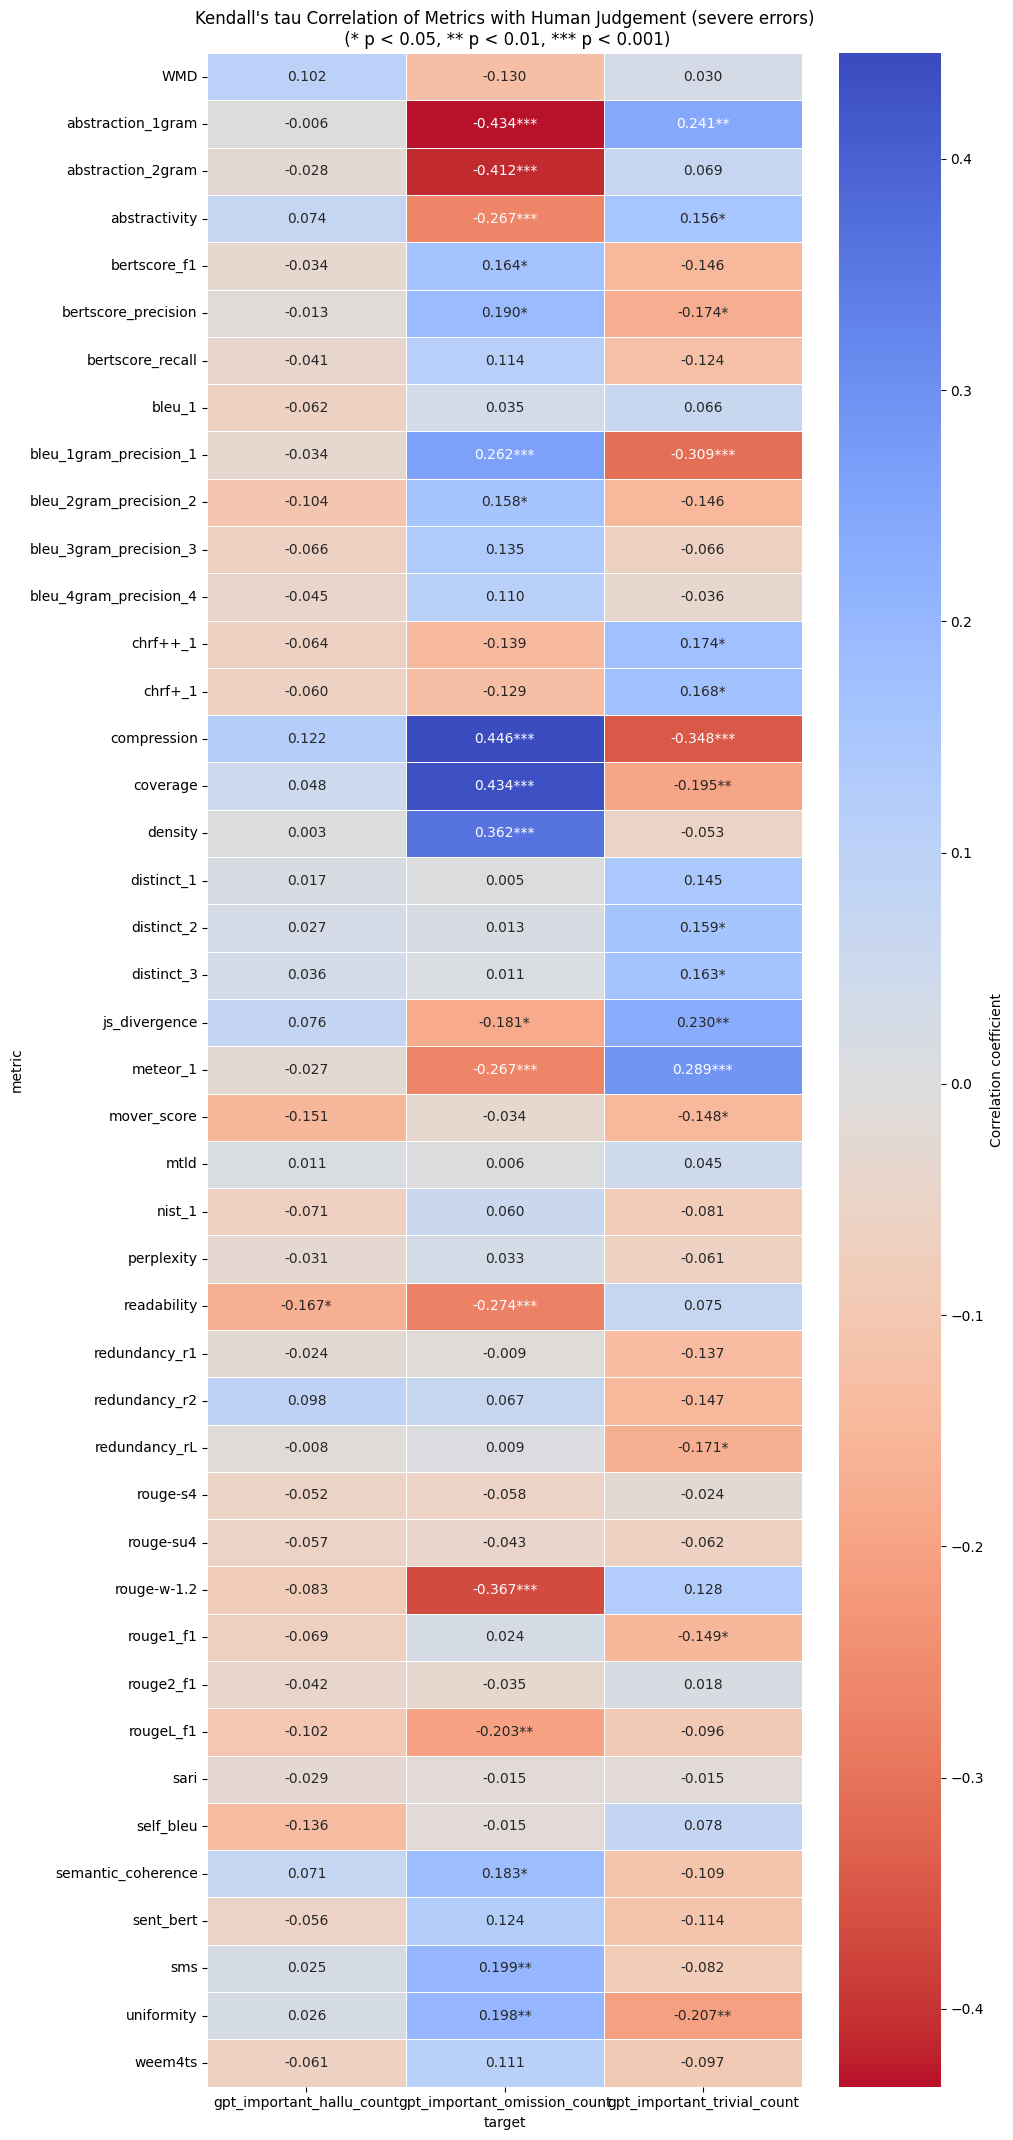

In [11]:
# IMPORTANT ERRORS 
# kendall's tau heatmap
kendall_heatmap_data = corr_df_important[corr_df_important['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='correlation')
kendall_annot_data = corr_df_important[corr_df_important['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='annot')
reorder_column_important = ['gpt_important_hallu_count', 'gpt_important_omission_count', 'gpt_important_trivial_count']
kendall_annot_data = kendall_annot_data[reorder_column_important]
kendall_heatmap_data = kendall_heatmap_data[reorder_column_important]
# Plot
plt.figure(figsize=(10, len(metric_columns) * 0.5 ))
sns.heatmap(
    kendall_heatmap_data,
    annot=kendall_annot_data,
    fmt='',
    cmap='coolwarm_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title("Kendall's tau Correlation of Metrics with Human Judgement (severe errors)\n (* p < 0.05, ** p < 0.01, *** p < 0.001)")
plt.tight_layout()
plt.show()

In [6]:
# IMPORTANT ERRORS 
# EXPORT TO EXCEL 
export_table = kendall_annot_data.astype(str)

# Export to Excel
export_table.to_excel("nl_kendall_tau_table_important.xlsx")

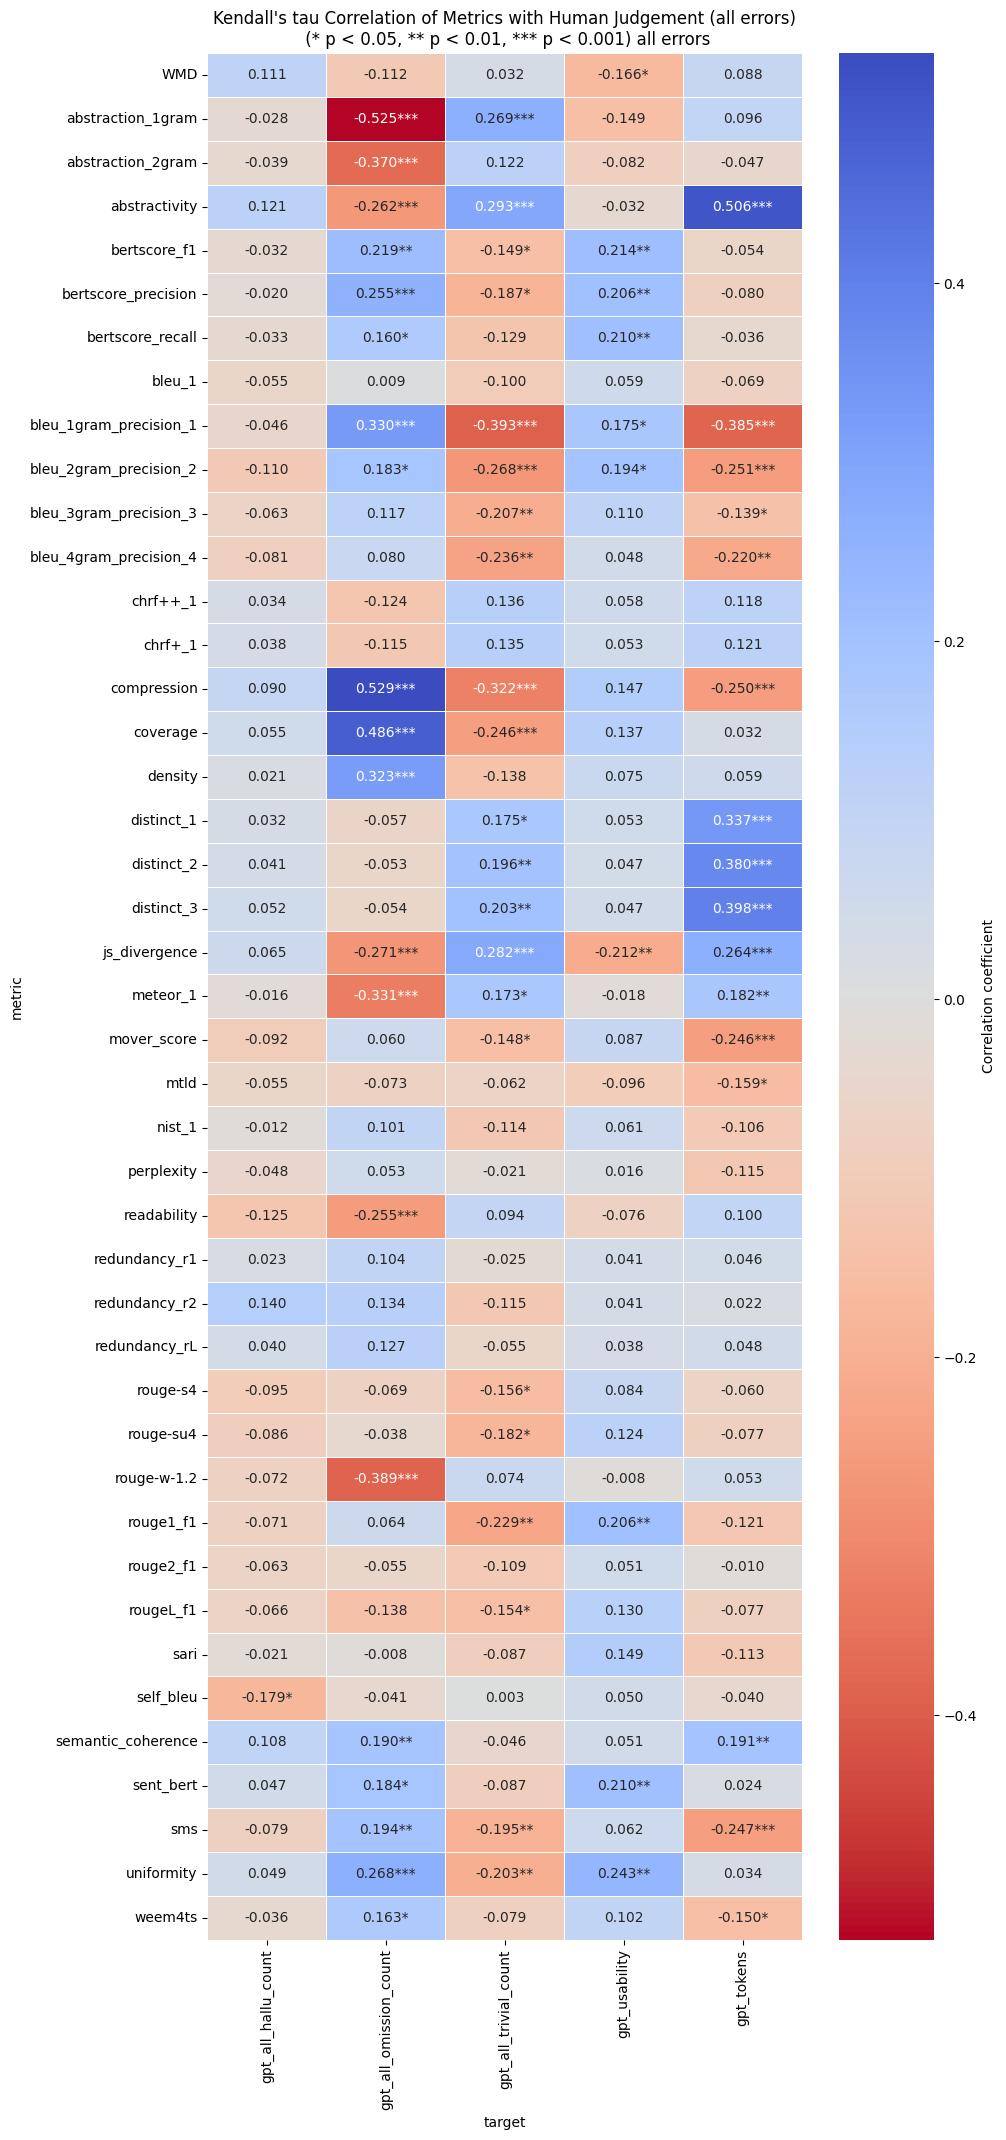

In [13]:
# ALL ERRORS 
# kendall's tau heatmap
kendall_heatmap_data_all = corr_df_all[corr_df_all['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='correlation')
kendall_annot_data_all = corr_df_all[corr_df_all['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='annot')
reorder_column_all = ['gpt_all_hallu_count', 'gpt_all_omission_count', 'gpt_all_trivial_count', 'gpt_usability', 'gpt_tokens']
kendall_annot_data_all = kendall_annot_data_all[reorder_column_all]
kendall_heatmap_data_all = kendall_heatmap_data_all[reorder_column_all]
# Plot
plt.figure(figsize=(10, len(metric_columns) * 0.5 ))
sns.heatmap(
    kendall_heatmap_data_all,
    annot=kendall_annot_data_all,
    fmt='',
    cmap='coolwarm_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title("Kendall's tau Correlation of Metrics with Human Judgement (all errors)\n (* p < 0.05, ** p < 0.01, *** p < 0.001) all errors")
plt.tight_layout()
plt.show()

In [ ]:
# ALL ERRORS 
# EXPORT TO EXCEL 
export_table_all = kendall_annot_data_all.astype(str)

# Export to Excel
export_table_all.to_excel("nl_kendall_tau_table_all.xlsx")

## Kendall's tau by group

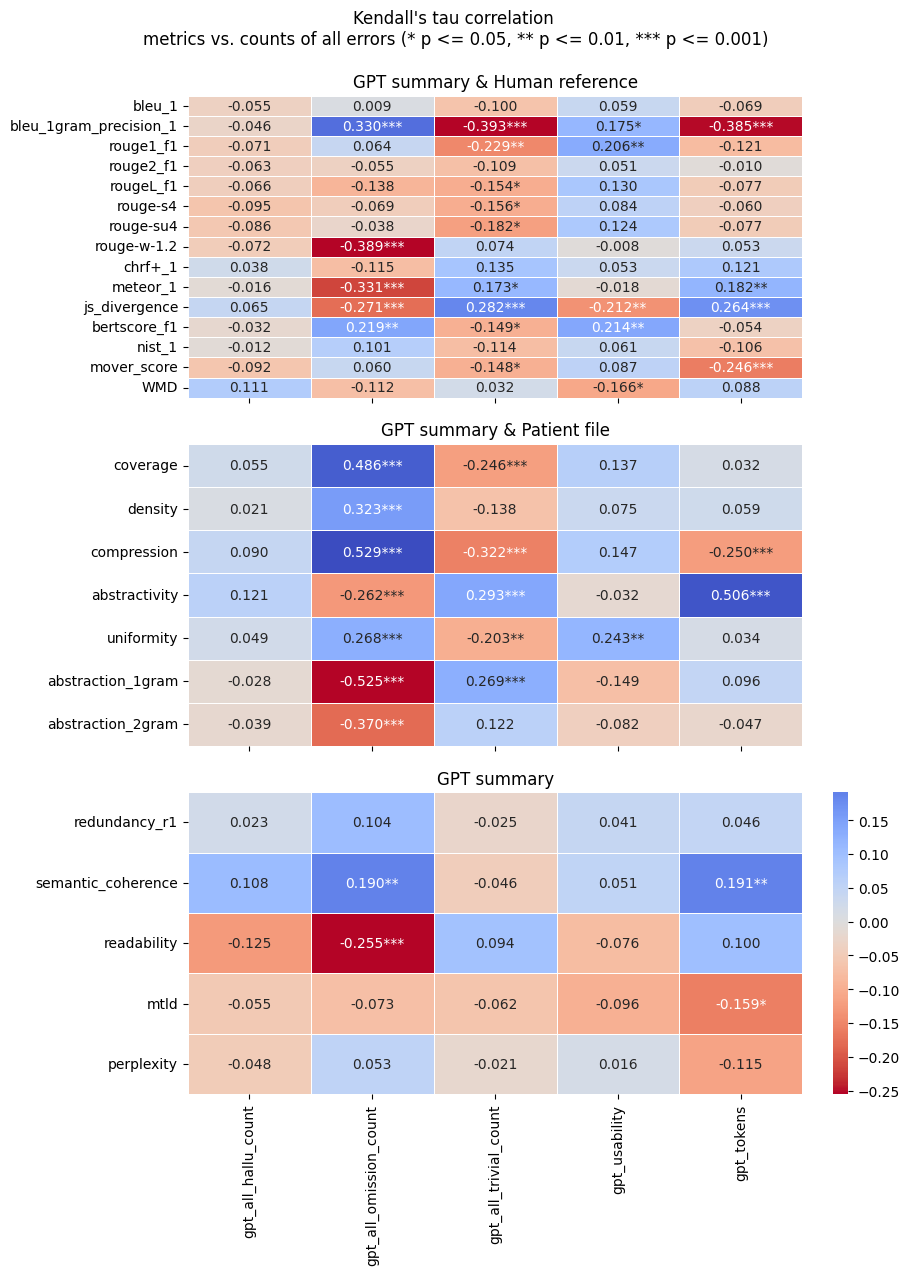

In [17]:
# FOR ALL ERRORS 
# plot by groups 
# Define groups
gen_ref = ['bleu_1', 'bleu_1gram_precision_1', 
           'rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'rouge-s4', 'rouge-su4', 'rouge-w-1.2' ,'chrf+_1', 'meteor_1', 'js_divergence',
           'bertscore_f1', 'nist_1', 'mover_score', 'WMD']

gen_source = ['coverage', 'density', 'compression', 'abstractivity', 'uniformity', 
              'abstraction_1gram', 'abstraction_2gram']

gen_only = ['redundancy_r1','semantic_coherence', 'readability', 'mtld', 'perplexity'] #'perplexity'

groups = {"GPT summary & Human reference": gen_ref, "GPT summary & Patient file": gen_source, "GPT summary": gen_only}

# Use pivot_table to handle duplicates
kendall_heatmap_data = (
    corr_df_all[corr_df_all['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='correlation', aggfunc='mean')
)
kendall_annot_data = (
    corr_df_all[corr_df_all['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='annot', aggfunc='first')
)

kendall_annot_data = kendall_annot_data[target_columns_all]
kendall_heatmap_data = kendall_heatmap_data[target_columns_all]

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True, sharey=False, layout='constrained')

for ax, (group_name, metrics) in zip(axs, groups.items()):
    sns.heatmap(
        kendall_heatmap_data.loc[metrics],   # only that group’s rows
        annot=kendall_annot_data.loc[metrics],
        fmt='',
        cmap='coolwarm_r',
        center=0,
        linewidths=0.5,
        cbar=(ax == axs[-1]),   # show colorbar only on last subplot
        # cbar_kws={'label': 'Correlation coefficient'} if ax == axs[-1] else None,
        ax=ax
    )
    ax.set_title(group_name)
    ax.set_xlabel('')
    ax.set_ylabel('')


fig.suptitle("Kendall's tau correlation \nmetrics vs. counts of all errors (* p <= 0.05, ** p <= 0.01, *** p <= 0.001)", y=1.05)
fig.set_constrained_layout_pads(hspace=0.06)
plt.show()


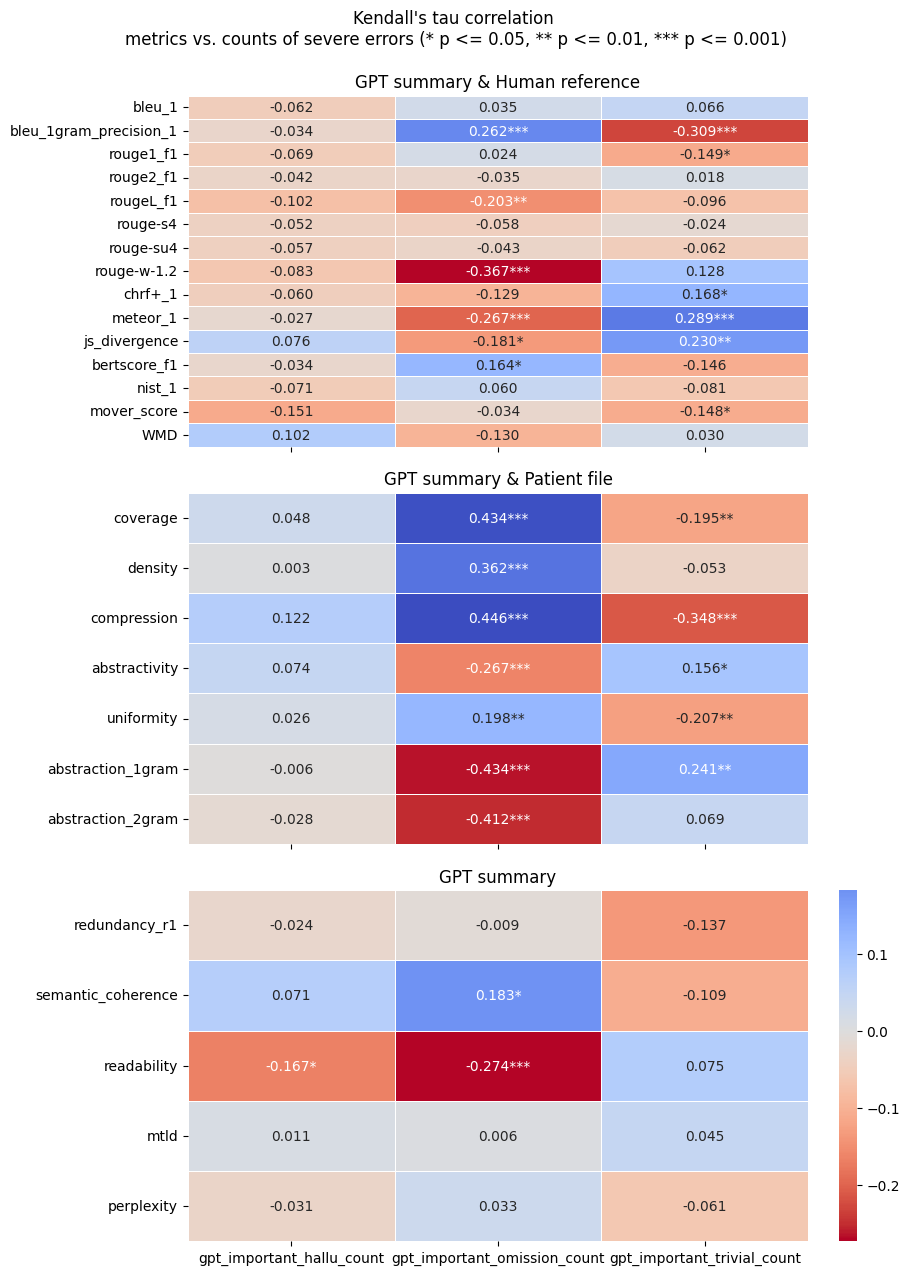

In [19]:
# FOR IMPORTANT ERRORS 
# plot by groups 
# Define groups - the same as previous cell

# Use pivot_table to handle duplicates
kendall_heatmap_data_important = (
    corr_df_important[corr_df_important['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='correlation', aggfunc='mean')
)
kendall_annot_data_important = (
    corr_df_important[corr_df_important['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='annot', aggfunc='first')
)

kendall_annot_data_important = kendall_annot_data_important[target_columns_important]
kendall_heatmap_data_important = kendall_heatmap_data_important[target_columns_important]

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True, sharey=False, layout='constrained')

for ax, (group_name, metrics) in zip(axs, groups.items()):
    sns.heatmap(
        kendall_heatmap_data_important.loc[metrics],   # only that group’s rows
        annot=kendall_annot_data_important.loc[metrics],
        fmt='',
        cmap='coolwarm_r',
        center=0,
        linewidths=0.5,
        cbar=(ax == axs[-1]),   # show colorbar only on last subplot
        # cbar_kws={'label': 'Correlation coefficient'} if ax == axs[-1] else None,
        ax=ax
    )
    ax.set_title(group_name)
    ax.set_xlabel('')
    ax.set_ylabel('')


fig.suptitle("Kendall's tau correlation \nmetrics vs. counts of severe errors (* p <= 0.05, ** p <= 0.01, *** p <= 0.001)", y=1.05)
fig.set_constrained_layout_pads(hspace=0.06)
plt.show()


## Spearman correlation

In [10]:
# IMPORTANT ERROR 
# spearman heatmap

spearman_heatmap_data_important = corr_df_important[corr_df_important['method'] == "spearman r"].pivot(index='metric', columns='target', values='correlation')
spearman_annot_dat_important = corr_df_important[corr_df_important['method'] == "spearman r"].pivot(index='metric', columns='target', values='annot')

# # Plot
# plt.figure(figsize=(12, len(metric_columns) * 0.5 + 2))
# sns.heatmap(
#     spearman_heatmap_data,
#     annot=spearman_annot_data,
#     fmt='',
#     cmap='coolwarm_r',
#     center=0,
#     linewidths=0.5,
#     cbar_kws={'label': 'Correlation coefficient'}
# )
# plt.title("Spearman Correlation of Metrics with Human Judgement\n (* p < 0.05, ** p < 0.01, *** p < 0.001)")
# plt.tight_layout()
# plt.show()

# ALL ERROR
spearman_annot_data_all = corr_df_all[corr_df_all['method'] == "spearman r"].pivot(index='metric', columns='target', values='annot')


# EXPORT TO EXCEL 
export_table_all = pd.concat(
    [spearman_annot_dat_important, spearman_annot_data_all],
    axis=1
).astype(str)
# Export to Excel
export_table_all.to_excel("nl_spearman_table.xlsx")

## Correlation between annotation, token number, usability

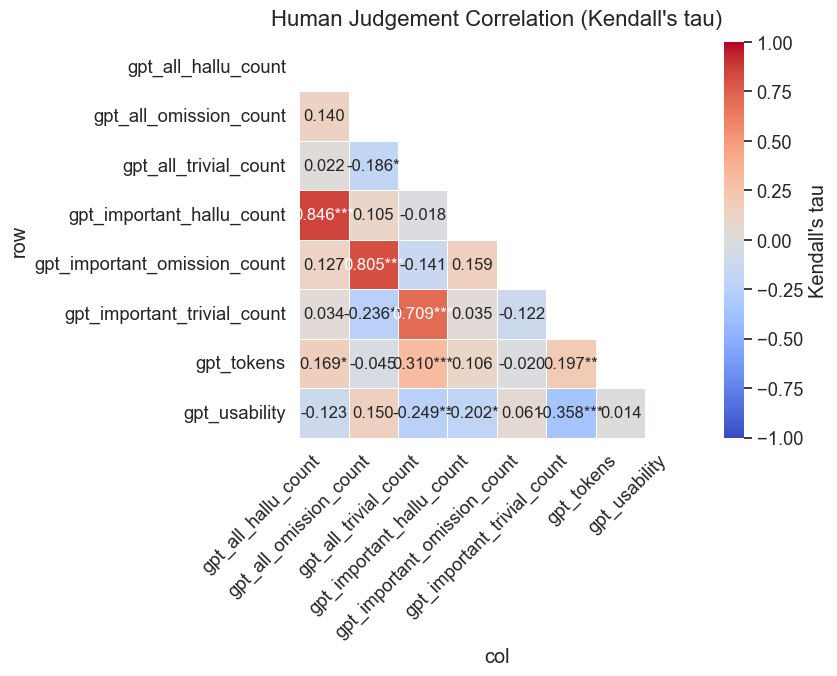

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Define your correlation function
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p

# Define target columns
target_columns = [
    'gpt_usability',
    'gpt_important_hallu_count',
    'gpt_important_omission_count',
    'gpt_important_trivial_count',
    'gpt_all_hallu_count',
    'gpt_all_omission_count',
    'gpt_all_trivial_count',
    'gpt_tokens'
]

subset = data_df[target_columns].dropna()

results = {
    'row': [],
    'col': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Compute correlations for all pairs (including diagonal)
for col1 in target_columns:
    for col2 in target_columns:
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            x = subset[col1]
            y = subset[col2]
            corr, p = compute_corr(method_func, x, y)
            results['row'].append(col1)
            results['col'].append(col2)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")

# Create DataFrame
human_corr_df = pd.DataFrame(results)

# Filter for kendall only
kendall_df = human_corr_df[human_corr_df['method'] == "kendall's tau"]

# Pivot to wide format
corr_matrix = kendall_df.pivot(index='row', columns='col', values='correlation')
annot_matrix = kendall_df.pivot(index='row', columns='col', values='annot')

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set plot style
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(9, 7))

# Draw heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    mask=mask,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': "Kendall's tau"},
    linewidths=0.7,
    square=True,
    annot_kws={"size": 12}
)

# Aesthetic settings
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Human Judgement Correlation (Kendall's tau)", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

#annot_matrix.to_excel('kendall_tau_human_anno.xlsx')

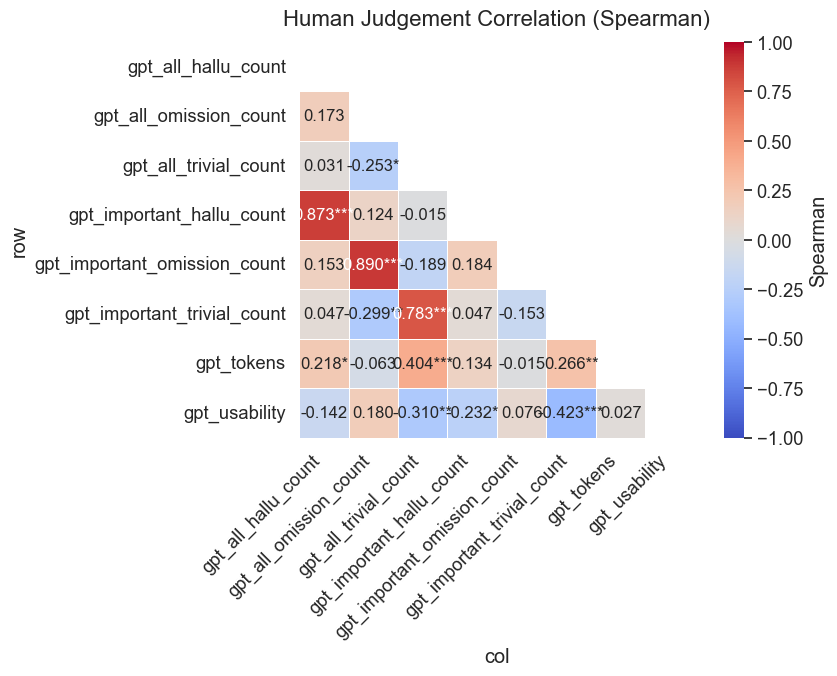

In [23]:
# spearman 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Define your correlation function
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p

# Define target columns
target_columns = [
    'gpt_usability',
    'gpt_important_hallu_count',
    'gpt_important_omission_count',
    'gpt_important_trivial_count',
    'gpt_all_hallu_count',
    'gpt_all_omission_count',
    'gpt_all_trivial_count',
    'gpt_tokens'
]

subset = data_df[target_columns].dropna()

results = {
    'row': [],
    'col': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Compute correlations for all pairs (including diagonal)
for col1 in target_columns:
    for col2 in target_columns:
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            x = subset[col1]
            y = subset[col2]
            corr, p = compute_corr(method_func, x, y)
            results['row'].append(col1)
            results['col'].append(col2)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")

# Create DataFrame
human_corr_df = pd.DataFrame(results)

# Filter for kendall only
spearman_df = human_corr_df[human_corr_df['method'] == "spearman r"]

# Pivot to wide format
corr_matrix = spearman_df.pivot(index='row', columns='col', values='correlation')
annot_matrix = spearman_df.pivot(index='row', columns='col', values='annot')

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set plot style
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(9, 7))

# Draw heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    mask=mask,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': "Spearman"},
    linewidths=0.7,
    square=True,
    annot_kws={"size": 12}
)

# Aesthetic settings
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Human Judgement Correlation (Spearman)", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

#annot_matrix.to_excel('spearman_human_anno.xlsx')

## Correlation between metrics

### error barplot

In [26]:
df_all = pd.concat([data_df, metric_df], axis=1)

In [27]:
pairs = {
    "gpt_all_hallu_count": ["abstractivity", "readability", "self_bleu"],
    "gpt_important_hallu_count": ["mover_score", "readability", "self_bleu"],
    "gpt_all_omission_count": ["compression", "coverage", "abstractivity"],
    "gpt_important_omission_count": ["compression", "coverage", "abstractivity"],
    "gpt_all_trivial_count": ["bleu_1gram_precision_1", "compression", "abstractivity"],
    "gpt_important_trivial_count": ["bleu_1gram_precision_1", "js_divergence", "compression"]
}

In [28]:
import numpy as np
import pandas as pd

plot_df = []

for error_col, metrics in pairs.items():
    for metric in metrics:

        tmp = df_all[[error_col, metric]].copy()

        tmp["error_group"] = np.where(tmp[error_col] == 0, "No error", "Error present")
        tmp["error_type"] = error_col
        tmp["metric"] = metric
        tmp["value"] = tmp[metric]

        plot_df.append(tmp[["error_type", "metric", "error_group", "value"]])

plot_df = pd.concat(plot_df, ignore_index=True)

In [29]:
error_labels = {
    "gpt_all_hallu_count": "All Hallucinations",
    "gpt_important_hallu_count": "Important Hallucinations",
    "gpt_all_omission_count": "All Omissions",
    "gpt_important_omission_count": "Important Omissions",
    "gpt_all_trivial_count": "All Trivial Facts",
    "gpt_important_trivial_count": "Important Trivial Facts"
}

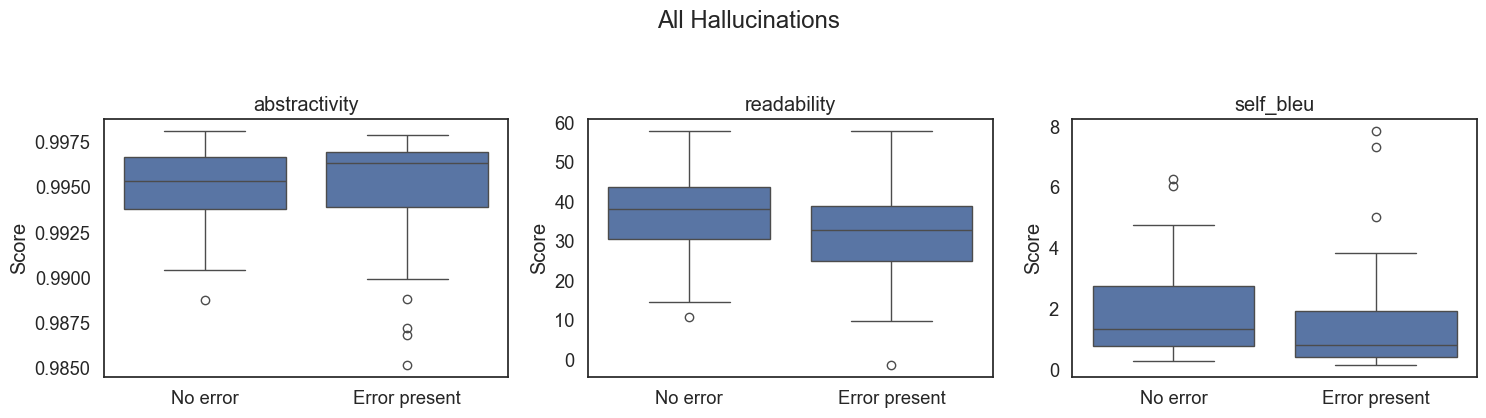

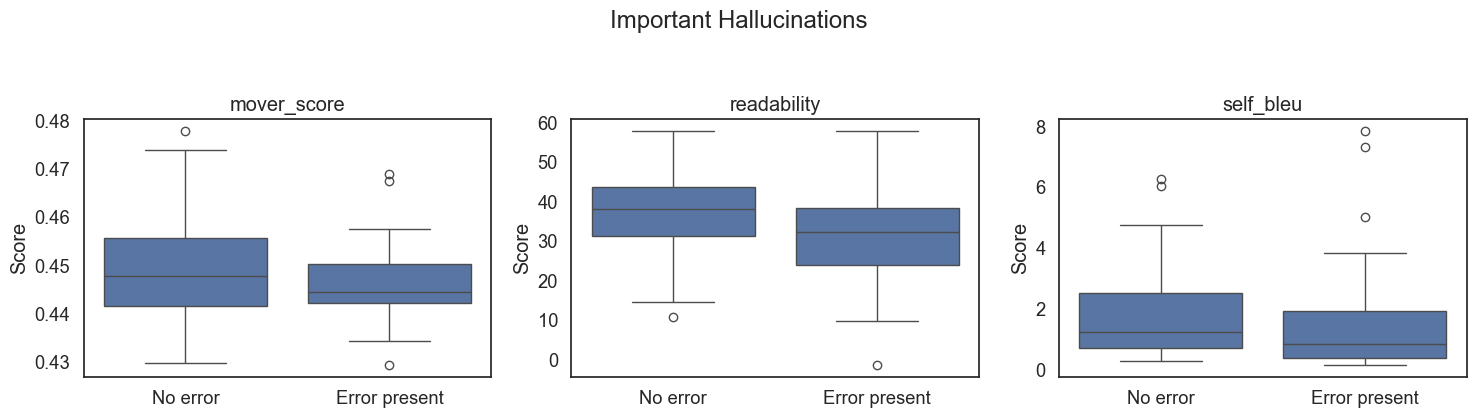

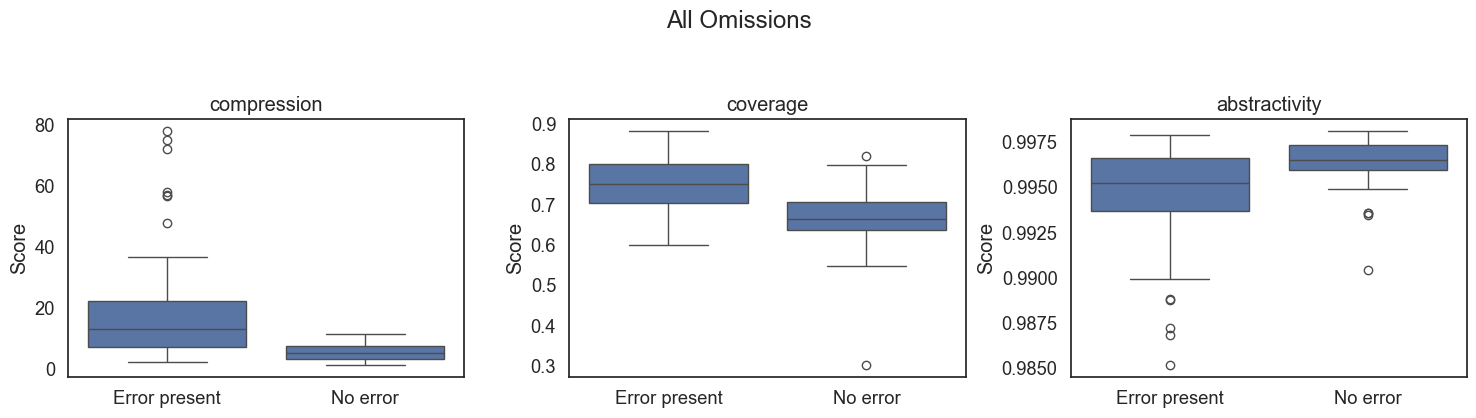

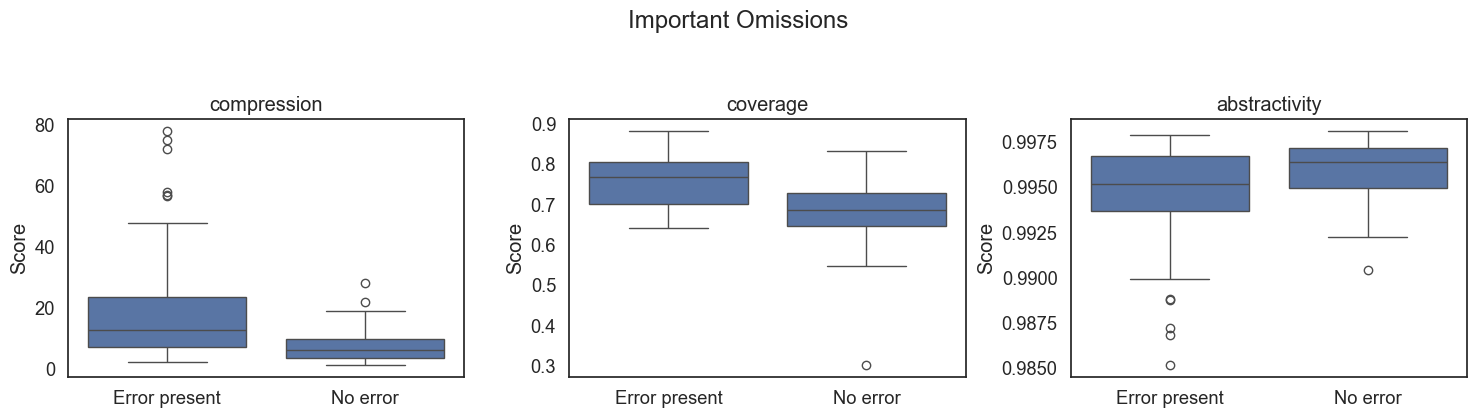

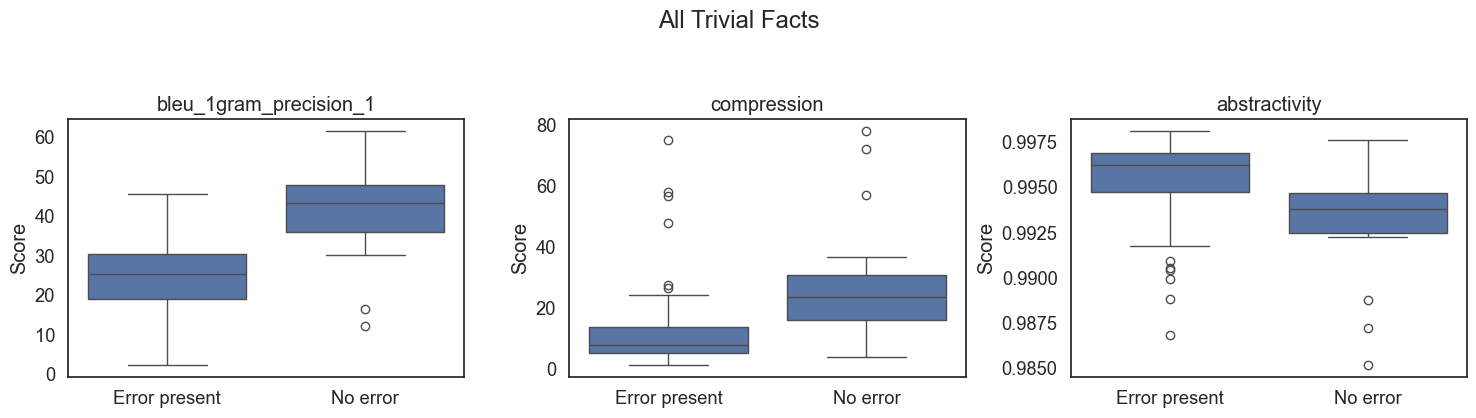

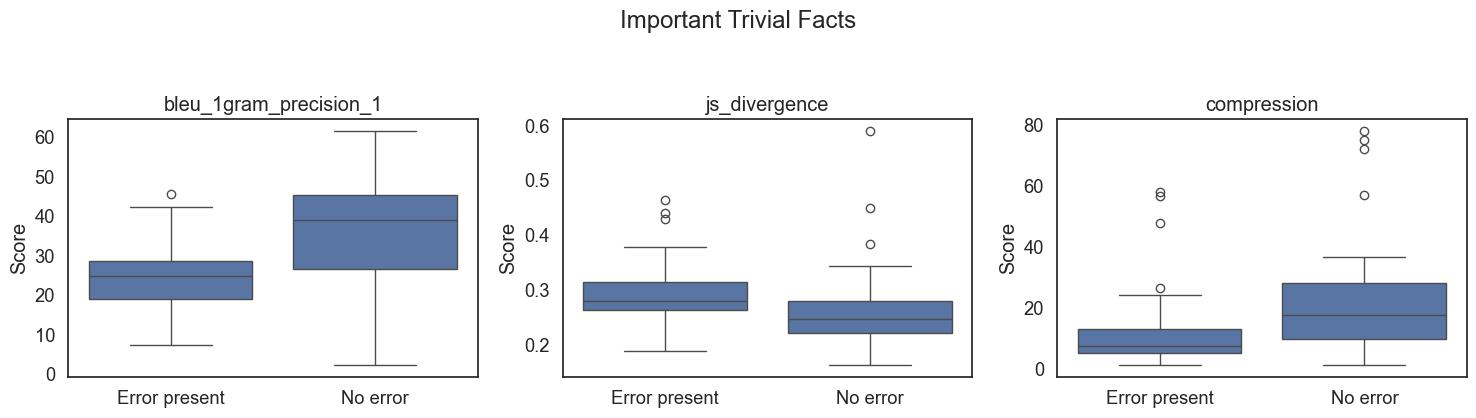

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for error_col, metrics in pairs.items():

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), sharey=False)

    if len(metrics) == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):

        tmp = df_all[[error_col, metric]].copy()
        tmp["error_group"] = np.where(tmp[error_col] == 0, "No error", "Error present")
        tmp = tmp.dropna()

        sns.boxplot(
            data=tmp,
            x="error_group",
            y=metric,
            ax=axes[i]
        )

        axes[i].set_title(metric)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Score")

    fig.suptitle(error_labels.get(error_col, error_col), y=1.05)
    plt.tight_layout()
    plt.show()

### Mann-Whitney U test 

In [31]:


from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

GROUP_A = 'No error'
GROUP_B = 'Error present'
ALPHA = 0.05

results = []

def fmt_p(p):
    if p < 0.001:
        return f'{p:.2e}'   # → 1.59e-07
    return f'{p:.3f}'       # → 0.034

for error_type in plot_df['error_type'].unique():
    for metric in plot_df['metric'].unique():
        sub = plot_df[(plot_df['error_type'] == error_type) & (plot_df['metric'] == metric)]
        a = sub[sub['error_group'] == GROUP_A]['value'].values
        b = sub[sub['error_group'] == GROUP_B]['value'].values

        if len(a) < 3 or len(b) < 3:
            continue  # skip if too few observations

        stat, p = mannwhitneyu(a, b, alternative='two-sided')

        results.append({
            'error_type': error_type,
            'metric': metric,
            'U_statistic': stat,
            'p_value': p,
            'size_median_no_error': (len(a), pd.Series(a).median().round(2)),
            'size_median_error': (len(b), pd.Series(b).median().round(2)),
            'direction': '↑ no error' if pd.Series(a).median().round(3) > pd.Series(b).median().round(3) else '↓ no error'
        })

claude_results_df = pd.DataFrame(results)

# FDR correction across all tests together
reject, p_fdr, _, _ = multipletests(claude_results_df['p_value'], method='fdr_bh', alpha=ALPHA)
claude_results_df['p_fdr'] = p_fdr
claude_results_df['significant'] = reject

claude_results_df['p_fdr_display'] = claude_results_df['p_fdr'].apply(fmt_p)
claude_results_df['p_value_display'] = claude_results_df['p_value'].apply(fmt_p)

print(claude_results_df.to_string(index=False))

                  error_type                 metric  U_statistic      p_value size_median_no_error size_median_error  direction    p_fdr  significant p_fdr_display p_value_display
         gpt_all_hallu_count          abstractivity       1042.0 3.388480e-01            (47, 1.0)         (50, 1.0) ↓ no error 0.338848        False         0.339           0.339
         gpt_all_hallu_count            readability       1435.0 6.104264e-02          (47, 38.07)       (50, 32.89) ↑ no error 0.073251        False         0.073           0.061
         gpt_all_hallu_count              self_bleu       1471.0 3.292058e-02           (47, 1.34)        (50, 0.78) ↑ no error 0.042326         True         0.042           0.033
   gpt_important_hallu_count            readability       1497.0 1.290609e-02          (55, 38.07)       (42, 32.22) ↑ no error 0.019359         True         0.019           0.013
   gpt_important_hallu_count              self_bleu       1395.0 8.120767e-02           (55, 1.22)  

In [60]:
claude_results_df.to_excel("./correlation table/mann-whitney.xlsx", index=False)